In [1]:
#Import Packages
import numpy as np
import matplotlib.pyplot as plt
import astropy 
from astropy.constants import M_sun
from astropy import units as u
from astropy.constants import c
from astropy.constants import L_sun
from matplotlib.gridspec import GridSpec as gs
L_sun_eps = L_sun.cgs.value
#plotsdir = "/mnt/home/kprofit/plots/"
plotsdir = "/beegfs/general/kprofit/binary_tests/al_td_96/plots"

In [2]:
#Constants Cell
c1 = [5.712,4.073] #c1 in soft and hard X-ray respectively
c2= [17.67,12.60] #c2 in soft and hard X-ray respectively
k1= [-0.026,0.278] #k1 in soft and hard X-ray respectively
k2= [0.278,0.278] #k2 in soft and hard X-ray respectively

c1_avg = [np.mean(c1)] #Mean c1 value between hard and soft x-ray
c2_avg = [np.mean(c2)] #Mean c2 value between hard and soft x-ray
k1_avg = [np.mean(k1)] #Mean k1 value between hard and soft x-ray
k2_avg = [np.mean(k2)] #Mean k2 value between hard and soft x-ray

In [3]:
#File Path cell
import sys
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0,'/beegfs/general/skoudmani/students/kasar/python/')
import read_snap_files as rsf
snap_dir_orig = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin"
#run_dir = "/beegfs/general/skoudmani/binary_proj/adios_runs/analysis/al_td"
#run_dir2 = "/beegfs/general/skoudmani/binary_proj/adios_runs/analysis/misal_td"
#snap_name = rsf.get_snap_filename(snap_dir_orig, 100, snap_prefix="snapshot")
snap_name = rsf.get_snap_filename(snap_dir_orig, 100, snap_prefix="snapshot")
unitlength_in_cm = rsf.get_attribute(snap_name, "UnitLength_in_cm", param=True) #How much one 'code length unit' is in cm
unitmass_in_g = rsf.get_attribute(snap_name, "UnitMass_in_g", param=True)  #How much one 'code mass unit' is in grams
unitvelocity_in_cm_per_s = rsf.get_attribute(snap_name, "UnitVelocity_in_cm_per_s", param=True)  #How much one 'code velocity unit' is in cm per second
unittime_in_s = unitlength_in_cm / unitvelocity_in_cm_per_s   #How much one 'code time unit' is in seconds


In [4]:
print(snap_name)
import os
print(os.path.exists(snap_name))

/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/snapshot_100.hdf5
True


In [5]:
#Functions Cell
def z1(a):
    return 1 + (1 - a**2)**(1/3)*(1+a)**(1/3)+(1-a)**(1/3) #Function of spin a
def z2(a):
    return np.sqrt(3*a**2 + z1(a)**2) #Function of spin a
def Lam(a):
    Lam1 = 3 + z2(a) - np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in prograde
    Lam2 = 3 + z2(a) + np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in retrograde
    return Lam1,Lam2
def eta(a,corotating=True): 
    Lam1,Lam2 = Lam(a)
    eta1 = 1 - np.sqrt(1-(2/(3*Lam1)))
    eta2 = 1 - np.sqrt(1-(2/(3*Lam2))) #Radiative effeciency 
    if corotating:
        return eta1 
    else:
        return eta2
    
    
def calculate_luminosities(a,mdot_cgs): 
    c_light_cgs = c.cgs.value 
    rad_eff = eta(a)
    print(np.shape(rad_eff))
    print(np.shape(mdot_cgs))
    L = rad_eff * mdot_cgs * c_light_cgs**2
    return L

def get_bol_correction(bol_lum,c1,c2,k1,k2):
    Lum_band = (bol_lum) / ((c1*(bol_lum/((10**10)*L_sun_eps))**k1)) + ((c2*(bol_lum/((10**10)*L_sun_eps))**k2))
    return Lum_band

def get_bol_correction_avg(bol_lum,c1_avg,c2_avg,k1_avg,k2_avg):
    Lum_band_avg = (bol_lum) / ((c1_avg*(bol_lum/((10**10)*L_sun_eps))**k1_avg)) + ((c2_avg*(bol_lum/((10**10)*L_sun_eps))**k2_avg))
    return Lum_band_avg

0
(9001,)
(9001,)
(9001,)
(9001,)
1.828899367238796e+41
2.5132315671596875e+40
1.9682495172698337e+41
2.783751166688153e+40


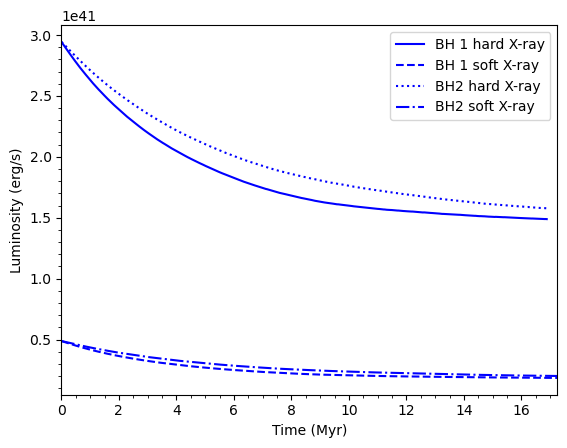

In [13]:
##Load in txt files for details on BH and BH spin
run_dir = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/blackhole_details/" #al_td is a standard case (not misaligned) and 1:1 mass ratio
run_dir2 = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/blackhole_details/" #misal_td is a 1:3 mass ratio and the binary is misaligned by 45 degrees w.r.t the circumbinary disk
#run_dir1 = "/mnt/home/skoudmani/ceph/ADIOSProj/CIRCUMBINARY/NEW_SIM/q10e00i00/analysis/"
#run_dir2 = "/mnt/home/skoudmani/ceph/ADIOSProj/CIRCUMBINARY/NEW_SIM/q03e00i00/analysis/"
details_file = "bh1_details.dat"
spin_file = "bh1_bhspin.dat"
details_file2 = "bh2_details.dat"
spin_file2 = "bh2_bhspin.dat"

colors = ["blue", "green"]
titles = ["q=1", "q=3"]

#Plot x-ray luminosities
for i,this_dir in enumerate([run_dir]): #, run_dir2]):
    print(i)
    spin_data = np.loadtxt(this_dir+spin_file)
    bh_data = np.loadtxt(this_dir+details_file)
    bh_data2 = np.loadtxt(this_dir+details_file2)
    spin_data2 = np.loadtxt(this_dir+spin_file2)
    time = spin_data[:,0][:9001] * 0.978462
    spin = spin_data[:,3][:9001]
    time2 = spin_data2[:,0][:9001]
    spin2 = spin_data2[:,3][:9001]
    efficiency = eta(spin, corotating=True)
    efficiency2 = eta(spin2, corotating=True)

    mdot = bh_data[:,2][:9001]
    mdot2 = bh_data2[:,2][:9001]
    mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
    mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
    mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1

    luminosities = calculate_luminosities(spin ,mdot_cgs)
    luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)
    
    xray_h1 = get_bol_correction(luminosities,c1[1],c2[1],k1[1],k2[1])
    xray_s1 = get_bol_correction(luminosities,c1[0],c2[0],k1[0],k2[0])
    xray_h2 = get_bol_correction(luminosities2,c1[1],c2[1],k1[1],k2[1])
    xray_s2 = get_bol_correction(luminosities2,c1[0],c2[0],k1[0],k2[0])
    
    xray_1 = get_bol_correction_avg(luminosities,c1_avg,c2_avg,k1_avg,k2_avg)
    xray_2 = get_bol_correction_avg(luminosities2,c1_avg,c2_avg,k1_avg,k2_avg)
    
    
    #plt.plot(time, , 'b', label='BH 1 soft X-ray')
    plt.plot(time,xray_h1, colors[i], label='BH 1 hard X-ray')
    plt.plot(time2,xray_s1, colors[i], label='BH 1 soft X-ray', ls="--")
    plt.plot(time,xray_h2, colors[i], label = 'BH2 hard X-ray', ls=':')
    plt.plot(time2,xray_s2, colors[i], label = 'BH2 soft X-ray', ls='-.')
    
    print(np.mean(xray_h1))
    print(np.mean(xray_s1))
    print(np.mean(xray_h2))
    print(np.mean(xray_s2))
    
    #plt.plot(time2,L_band_h2, 'k--', label='BH 2 hard X-ray')                
    plt.ylabel("Luminosity (erg/s)")
    plt.xlabel("Time (Myr)")
    plt.minorticks_on()
    plt.style.context('bmh')
    plt.legend(loc=1)
    plt.margins(x=0)
    #plt.axhline(y=np.mean(xray_h1), color='r', linestyle='-')
    #plt.axhline(y=np.mean(luminosities2), color='r', linestyle='--')

0
(9001,)
(9001,)
(9001,)
(9001,)
[0.9      0.9      0.9      ... 0.900219 0.900219 0.900219]


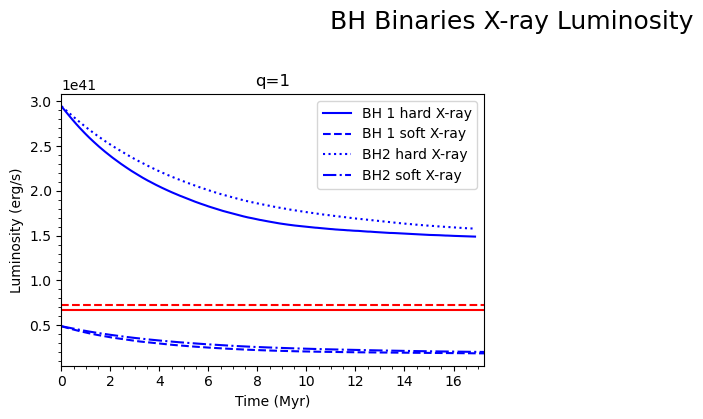

In [15]:
#Create subplots for each iteration of hard and soft x-ray luminosity using gridsspec

plt.figure(figsize=(12, 12))
plt.subplots_adjust()
plt.suptitle("BH Binaries X-ray Luminosity", fontsize=18, y=0.95)

#print(np.mean(xray_h1[i]))
#print(np.mean(xray_s1[i]))
#print(np.mean(xray_h2[i]))
#print(np.mean(xray_s2[i]))

#loop through the length of tickers and keep track of index
for i, this_dir in enumerate([run_dir]): #, run_dir2]):
    print(i)
    #Load in data
    spin_data = np.loadtxt(this_dir+spin_file)
    bh_data = np.loadtxt(this_dir+details_file)
    bh_data2 = np.loadtxt(this_dir+details_file2)
    spin_data2 = np.loadtxt(this_dir+spin_file2)
    time = spin_data[:,0][:9001] * 0.978462
    spin = spin_data[:,3][:9001]
    time2 = spin_data2[:,0][:9001]
    spin2 = spin_data2[:,3][:9001]
    efficiency = eta(spin, corotating=True)
    efficiency2 = eta(spin2, corotating=True)
    
    mdot = bh_data[:,2][:9001]
    mdot2 = bh_data2[:,2][:9001]
    mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
    mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
    mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    
    #calculate x-ray luminsoities
    luminosities = calculate_luminosities(spin ,mdot_cgs)
    luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)

    xray_h1 = get_bol_correction(luminosities,c1[1],c2[1],k1[1],k2[1])
    xray_s1 = get_bol_correction(luminosities,c1[0],c2[0],k1[0],k2[0])
    xray_h2 = get_bol_correction(luminosities2,c1[1],c2[1],k1[1],k2[1])
    xray_s2 = get_bol_correction(luminosities2,c1[0],c2[0],k1[0],k2[0])
    
    xray_1 = get_bol_correction_avg(luminosities,c1_avg,c2_avg,k1_avg,k2_avg)
    xray_2 = get_bol_correction_avg(luminosities2,c1_avg,c2_avg,k1_avg,k2_avg)

    #print("Mean spin1:", np.mean(spin))
    #print("Mean spin2:", np.mean(spin2))
    #print("Mean mdot1:", np.mean(mdot))
    #print("Mean mdot2:", np.mean(mdot2))
    #print("-------------------")


    # add a new subplot iteratively
    ax = plt.subplot(3, 2, i + 1)
    ax.plot(time, xray_h1, colors[i], label='BH 1 hard X-ray')
    ax.plot(time2,xray_s1, colors[i], label='BH 1 soft X-ray', ls="--")
    ax.plot(time,xray_h2, colors[i], label = 'BH2 hard X-ray', ls=':')
    ax.plot(time2,xray_s2, colors[i], label = 'BH2 soft X-ray', ls='-.')
    ax.legend(loc=1)
    ax.set_title(titles[i])
    
    #print(np.mean(xray_1))
    #print(np.mean(xray_2))
    #print(np.mean(xray_h2))
    #print(np.mean(xray_s2))
    print(spin)
    
    ax.axhline(y=np.mean(xray_1), color='r', linestyle='-') #Mean x-ray luminosity for BH1
    #ax.axhline(y=np.mean(xray_s1), color='r', linestyle='--')
    ax.axhline(y=np.mean(xray_2), color='r', linestyle='--') #Mean x-ray luminosity for BH2
    #ax.axhline(y=np.mean(xray_s2), color='r', linestyle='--')
#chart formatting
    ax.margins(x=0)
    plt.style.context('bmh')
    ax.set_xlabel("Time (Myr)")
    ax.minorticks_on()
    ax.set_ylabel("Luminosity (erg/s)")
    plt.savefig("BH_x-ray_lum", bbox_inches='tight')